# Final Project / Additional EDA
## Ashley Mann

#### CMPINF2100  |  Introduction to Data-Centric Computing — August 2026

***

# Background & Context

The final project follows up on the EDA assignment with predictive modeling and evaluation. This analysis will allow you to measure associations with song popularity in the Spotify Songs dataset and build and evaluate models that can predict song popularity from song metadata.

### Jupyter Notebook Formatting

Like the EDA, this assignment will be completed with Jupyter Notebook on your own computer. It is graded by teaching staff.

Different from the EDA, however, you will create and submit multiple notebooks:

- A main notebook which includes answers to the lettered sections below (A, B, C, etc.). This main notebook should contain key code and visualizations, as well as important discussion and interpretation. Answers to all questions in the instructions must be included in this main notebook since that is the only notebook guaranteed to be examined by teaching staff for grading. Please name this main notebook final_project_main.ipynb. 

- Supporting notebooks that go in more detail for specific sections and can contain things that you tried but didn't end up being important for analysis, other unimportant figures and code, or anything else. Explanations and discussions are not required for supporting notebooks, which may or may not be reviewed by grading staff. Names of these notebooks should correspond to sections, such as model_fitting_supporting.ipynb, etc. If you refer to plots and findings from an EDA, you can submit an eda_supporting.ipynb notebook, as well. This can simply be a copy of your EDA assignment, but can also include any additions or revisions you did since you completed the EDA assignment.

## Dataset

For the final project, you will continue to use the Spotify Songs dataset that you explored in the EDA assignment. Here is  Here is a direct URL to the dataset CSV to read in to your notebook with Pandas: https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv   

## Final Project Goals

In the EDA, we aimed to understand how the values of variables can be used to predict the value of another variable. Now, we will use predictive modeling and evaluation to measure song popularity.

<span style="color:#E2725B">

- **Current Goal:** Predict a song's popularity based on the features associated with a song.

- **Previous Goal:** Understand the breadth of this dataset, keeping in mind values and features of the data that prepare us to consider prediction.

</span>

## Data Dictionary

| variable | class | description |
|----------|-------|-------------|
| track_id | character | Song unique ID |
| track_name | character | Song Name |
| track_artist | character | Song Artist |
| track_popularity | double | Song Popularity (0-100) where higher is better |
| track_album_id | character | Album unique ID |
| track_album_name | character | Song album name |
| track_album_release_date | character | Date when album released |
| playlist_name | character | Name of playlist |
| playlist_id | character | Playlist ID |
| playlist_genre | character | Playlist genre |
| playlist_subgenre | character | Playlist subgenre |
| danceability | double | Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable. |
| energy | double | Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale. Perceptual features contributing to this attribute include dynamic range, perceived loudness, timbre, onset rate, and general entropy. |
| key | double | The estimated overall key of the track. Integers map to pitches using standard Pitch Class notation . E.g. 0 = C, 1 = C#/Db, 2 = D, and so on. If no key was detected, the value is -1. |
| loudness | double | The overall loudness of a track in decibels (dB). Loudness values are averaged across the entire track and are useful for comparing relative loudness of tracks. Loudness is the quality of a sound that is the primary psychological correlate of physical strength (amplitude). Values typical range between -60 and 0 db. |
| mode | double | Mode indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0. |
| speechiness | double | Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks. |
| acousticness | double | A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic. |
| instrumentalness | double | Predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal". The closer the instrumentalness value is to 1.0, the greater the likelihood the track contains no vocal content. Values above 0.5 are intended to represent instrumental tracks, but confidence is higher as the value approaches 1.0. |
| liveness | double | Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live. |
| valence | double | A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry). |
| tempo | double | The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration. |
| duration_ms | double | Duration of song in milliseconds |

<span style="color:#E2725B">

## Additional EDA Outline

- Lorem ipsum **Part 1. Summary** 

- Lorem ipsum **Part 2: Model Fitting and Interpretation** 

- Lorem ipsum **Part 3: Model Predictions**

- Lorem ipsum **Part 4: Model Generalization Performance with Cross-validation** 

</span>

***

<span style="color:#17A697">

# 1. Data Loading (and Imports)

</span>

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [6]:
df = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv')
df.head(10)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052
5,7fvUMiyapMsRRxr07cU8Ef,Beautiful People (feat. Khalid) - Jack Wins Remix,Ed Sheeran,67,2yiy9cd2QktrNvWC2EUi0k,Beautiful People (feat. Khalid) [Jack Wins Remix],2019-07-11,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,8,-5.385,1,0.1270,0.0799,0.000000,0.1430,0.585,124.982,163049
6,2OAylPUDDfwRGfe0lYqlCQ,Never Really Over - R3HAB Remix,Katy Perry,62,7INHYSeusaFlyrHSNxm8qH,Never Really Over (R3HAB Remix),2019-07-26,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,5,-4.788,0,0.0623,0.1870,0.000000,0.1760,0.152,112.648,187675
7,6b1RNvAcJjQH73eZO4BLAB,Post Malone (feat. RANI) - GATTÜSO Remix,Sam Feldt,69,6703SRPsLkS4bPtMFFJes1,Post Malone (feat. RANI) [GATTÜSO Remix],2019-08-29,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,4,-2.419,0,0.0434,0.0335,0.000005,0.1110,0.367,127.936,207619
8,7bF6tCO3gFb8INrEDcjNT5,Tough Love - Tiësto Remix / Radio Edit,Avicii,68,7CvAfGvq4RlIwEbT9o8Iav,Tough Love (Tiësto Remix),2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,8,-3.562,1,0.0565,0.0249,0.000004,0.6370,0.366,127.015,193187
9,1IXGILkPm0tOCNeq00kCPa,If I Can't Have You - Gryffin Remix,Shawn Mendes,67,4QxzbfSsVryEQwvPFEV5Iu,If I Can't Have You (Gryffin Remix),2019-06-20,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,2,-4.552,1,0.0320,0.0567,0.000000,0.0919,0.590,124.957,253040


***

<span style="color:#17A697">

# 1. Initial Exploration

</span>

<span style="color:#E2725B">

Everything in this section explores details for the original read-in dataset.

</span>

In [7]:
df.shape

(32833, 23)

In [8]:
df.dtypes

track_id                        str
track_name                      str
track_artist                    str
track_popularity              int64
track_album_id                  str
track_album_name                str
track_album_release_date        str
playlist_name                   str
playlist_id                     str
playlist_genre                  str
playlist_subgenre               str
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object

In [9]:
df.isna().sum()

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

In [10]:
df.nunique()

track_id                    28356
track_name                  23449
track_artist                10692
track_popularity              101
track_album_id              22545
track_album_name            19743
track_album_release_date     4530
playlist_name                 449
playlist_id                   471
playlist_genre                  6
playlist_subgenre              24
danceability                  822
energy                        952
key                            12
loudness                    10222
mode                            2
speechiness                  1270
acousticness                 3731
instrumentalness             4729
liveness                     1624
valence                      1362
tempo                       17684
duration_ms                 19785
dtype: int64

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

In [12]:
df.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [13]:
df.select_dtypes('object').nunique()

/var/folders/n5/bcqsht_s1hb0n82hjngtzw240000gn/T/ipykernel_1584/3198987469.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes('object').nunique()


track_id                    28356
track_name                  23449
track_artist                10692
track_album_id              22545
track_album_name            19743
track_album_release_date     4530
playlist_name                 449
playlist_id                   471
playlist_genre                  6
playlist_subgenre              24
dtype: int64

***

<span style="color:#17A697">

# Part 3: Treatment of Variables (Start here!!!)

</span>

In [14]:
df['track_popularity_shifted'] = np.where(df.track_popularity == 100, df.track_popularity - 0.1, df.track_popularity)
df['track_popularity_shifted'] = np.where(df.track_popularity == 0, df.track_popularity + 0.1, df.track_popularity_shifted)  
df['track_popularity_fraction'] = df.track_popularity_shifted/100
df['track_popularity_transformed'] = np.log(df.track_popularity_fraction / (1 - df.track_popularity_fraction))  

<span style="color:#E2725B">

Transforming the variable for track popularity per the instructions.

</span>

In [15]:
key_var_df = df[['track_artist', 'tempo', 'danceability', 'energy', 'valence', 'track_popularity_transformed']]
key_var_df.head(10)

,track_artist,tempo,danceability,energy,valence,track_popularity_transformed
0,Ed Sheeran,122.036,0.748,0.916,0.518,0.663294
1,Maroon 5,99.972,0.726,0.815,0.693,0.708185
2,Zara Larsson,124.008,0.675,0.931,0.613,0.847298
3,The Chainsmokers,121.956,0.718,0.930,0.277,0.405465
4,Lewis Capaldi,123.976,0.650,0.833,0.725,0.800119
5,Ed Sheeran,124.982,0.675,0.919,0.585,0.708185
6,Katy Perry,112.648,0.449,0.856,0.152,0.489548
7,Sam Feldt,127.936,0.542,0.903,0.367,0.800119
8,Avicii,127.015,0.594,0.935,0.366,0.753772
9,Shawn Mendes,124.957,0.642,0.818,0.590,0.708185


<span style="color:#E2725B">

Creating a focused dataset for the key variables.

</span>

In [16]:
cont_var_df = df[['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']]
cont_var_df.head(10)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052
5,0.675,0.919,8,-5.385,1,0.1270,0.0799,0.000000,0.1430,0.585,124.982,163049
6,0.449,0.856,5,-4.788,0,0.0623,0.1870,0.000000,0.1760,0.152,112.648,187675
7,0.542,0.903,4,-2.419,0,0.0434,0.0335,0.000005,0.1110,0.367,127.936,207619
8,0.594,0.935,8,-3.562,1,0.0565,0.0249,0.000004,0.6370,0.366,127.015,193187
9,0.642,0.818,2,-4.552,1,0.0320,0.0567,0.000000,0.0919,0.590,124.957,253040


<span style="color:#E2725B">

Focusing on only continuous variables to prepare for standardization—the ones that haven't been logit transformed like the outcome variable.

</span>

In [17]:
cont_var_df_corr = cont_var_df.corr()
cont_var_df_corr

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
danceability,1.000000,-0.086073,0.011736,0.025335,-0.058647,0.181721,-0.024519,-0.008655,-0.123859,0.330523,-0.184084,-0.096879
energy,-0.086073,1.000000,0.010052,0.676625,-0.004800,-0.032150,-0.539745,0.033247,0.161223,0.151103,0.149951,0.012611
key,0.011736,0.010052,1.000000,0.000959,-0.174093,0.022607,0.004306,0.005968,0.002887,0.019914,-0.013370,0.015139
loudness,0.025335,0.676625,0.000959,1.000000,-0.019289,0.010339,-0.361638,-0.147824,0.077613,0.053384,0.093767,-0.115058
mode,-0.058647,-0.004800,-0.174093,-0.019289,1.000000,-0.063512,0.009415,-0.006741,-0.005549,0.002614,0.014329,0.015634
speechiness,0.181721,-0.032150,0.022607,0.010339,-0.063512,1.000000,0.026092,-0.103424,0.055426,0.064659,0.044603,-0.089431
acousticness,-0.024519,-0.539745,0.004306,-0.361638,0.009415,0.026092,1.000000,-0.006850,-0.077243,-0.016845,-0.112724,-0.081581
instrumentalness,-0.008655,0.033247,0.005968,-0.147824,-0.006741,-0.103424,-0.006850,1.000000,-0.005507,-0.175402,0.023335,0.063235
liveness,-0.123859,0.161223,0.002887,0.077613,-0.005549,0.055426,-0.077243,-0.005507,1.000000,-0.020560,0.021018,0.006138
valence,0.330523,0.151103,0.019914,0.053384,0.002614,0.064659,-0.016845,-0.175402,-0.020560,1.000000,-0.025732,-0.032225


<span style="color:#E2725B">

Focusing on only continuous variables to prepare for standardization.

</span>

In [18]:
scaler = StandardScaler()

In [19]:
scaler.fit(cont_var_df)

StandardScaler()

In [20]:
print(scaler.mean_)
print(scaler.scale_)

[ 6.54849520e-01  6.98619271e-01  5.37447081e+00 -6.71949913e+00
  5.65711327e-01  1.07068069e-01  1.75333715e-01  8.47471613e-02
  1.90176195e-01  5.10560974e-01  1.20881132e+02  2.25799812e+05]
[1.45083111e-01 1.80907279e-01 3.61160241e+00 2.98839088e+00
 4.95663214e-01 1.01312589e-01 2.19629196e-01 2.24226709e-01
 1.54314929e-01 2.33142424e-01 2.69032145e+01 5.98330950e+04]


<span style="color:#E2725B">

Using StandardScaler to show the mean and scale.

</span>

In [21]:
cont_var_df_std_arr = scaler.transform(cont_var_df)
cont_var_df_std_arr.shape

(32833, 12)

<span style="color:#E2725B">

Transforming the data.

</span>

In [22]:
cont_var_df_std = pd.DataFrame(cont_var_df_std_arr, columns = cont_var_df.columns)
cont_var_df_std.head(10)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.642049,1.201614,0.173200,1.367123,0.876177,-0.481362,-0.333898,-0.377953,-0.809230,0.031908,0.042927,-0.518874
1,0.490412,0.643317,1.557627,0.585766,0.876177,-0.688642,-0.468670,-0.359177,1.081061,0.782522,-0.777198,-1.056268
2,0.138889,1.284529,-1.211227,1.100090,-1.141322,-0.324422,-0.436799,-0.377849,-0.519562,0.439384,0.116227,-0.822017
3,0.435271,1.279002,0.450085,0.984309,0.876177,-0.050024,-0.667642,-0.377911,0.089582,-1.001795,0.039953,-0.947750
4,-0.033426,0.742815,-1.211227,0.685151,0.876177,-0.702460,-0.432701,-0.377953,-0.692585,0.919777,0.115037,-0.614172
5,0.138889,1.218197,0.726971,0.446561,0.876177,0.196737,-0.434522,-0.377953,-0.305714,0.319286,0.152430,-1.048764
6,-1.418839,0.869952,-0.103686,0.646334,-1.141322,-0.441881,0.053118,-0.377953,-0.091865,-1.537948,-0.306028,-0.637186
7,-0.777827,1.129754,-0.380571,1.439068,-1.141322,-0.628432,-0.645787,-0.377931,-0.513082,-0.615765,0.262231,-0.303859
8,-0.419411,1.306640,0.726971,1.056588,0.876177,-0.499129,-0.684944,-0.377935,2.895532,-0.620054,0.227998,-0.545063
9,-0.088567,0.659900,-0.934342,0.725306,0.876177,-0.740955,-0.540155,-0.377953,-0.636855,0.340732,0.151501,0.455270


<span style="color:#E2725B">

Final standardized values for the key continuous variables only.

</span>

In [23]:
cont_var_df_std.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04
mean,1.662038e-16,-2.458431e-16,-1.229215e-16,-2.908566e-16,-6.232641e-17,6.925157e-18,-7.963930e-17,-5.540125e-17,1.211902e-16,1.592786e-16,1.038774e-17,1.800541e-16
std,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,-4.513616e+00,-3.860786e+00,-1.488113e+00,-1.329428e+01,-1.141322e+00,-1.056809e+00,-7.983170e-01,-3.779530e-01,-1.232390e+00,-2.189910e+00,-4.493185e+00,-3.706975e+00
25%,-6.330821e-01,-6.501633e-01,-9.343417e-01,-4.857132e-01,-1.141322e+00,-6.521210e-01,-7.295647e-01,-3.779530e-01,-6.316705e-01,-7.701772e-01,-7.776443e-01,-6.347793e-01
50%,1.182114e-01,1.237138e-01,1.731999e-01,1.852164e-01,8.761769e-01,-4.399065e-01,-4.322454e-01,-3.778812e-01,-4.093978e-01,6.172306e-03,4.099393e-02,-1.637858e-01
75%,7.316529e-01,7.815093e-01,1.003856e+00,6.941860e-01,8.761769e-01,2.460892e-01,3.627309e-01,-3.564123e-01,3.747130e-01,7.825218e-01,4.845840e-01,4.643783e-01
max,2.261810e+00,1.665940e+00,1.557627e+00,2.675185e+00,8.761769e-01,8.004256e+00,3.727493e+00,4.055060e+00,5.221943e+00,2.060710e+00,4.406866e+00,4.880413e+00


<span style="color:#E2725B">

Summary statistics.

</span>

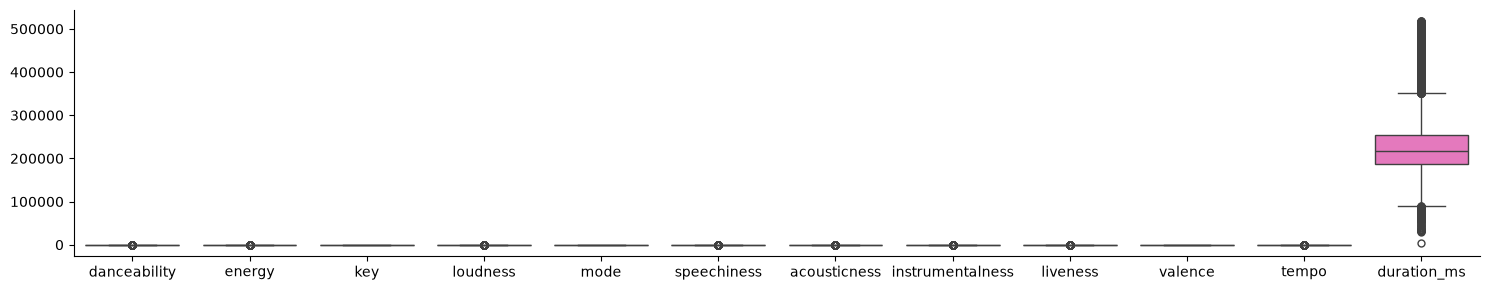

In [24]:
sns.catplot(data = cont_var_df, kind = 'box', height = 3, aspect = 5)
plt.show()

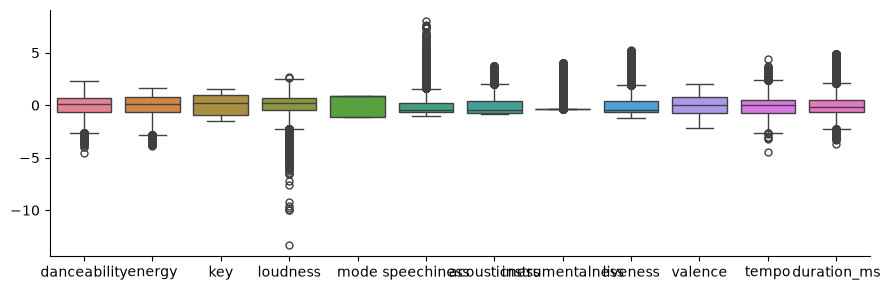

In [25]:
sns.catplot(data = cont_var_df_std, kind = 'box', height = 3, aspect = 3)
plt.show()

In [26]:
std_df_all = pd.concat([cont_var_df_std, df[['playlist_genre', 'playlist_subgenre', 'track_popularity_transformed']]], axis = 1)
std_df_all.head(10)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre,playlist_subgenre,track_popularity_transformed
0,0.642049,1.201614,0.173200,1.367123,0.876177,-0.481362,-0.333898,-0.377953,-0.809230,0.031908,0.042927,-0.518874,pop,dance pop,0.663294
1,0.490412,0.643317,1.557627,0.585766,0.876177,-0.688642,-0.468670,-0.359177,1.081061,0.782522,-0.777198,-1.056268,pop,dance pop,0.708185
2,0.138889,1.284529,-1.211227,1.100090,-1.141322,-0.324422,-0.436799,-0.377849,-0.519562,0.439384,0.116227,-0.822017,pop,dance pop,0.847298
3,0.435271,1.279002,0.450085,0.984309,0.876177,-0.050024,-0.667642,-0.377911,0.089582,-1.001795,0.039953,-0.947750,pop,dance pop,0.405465
4,-0.033426,0.742815,-1.211227,0.685151,0.876177,-0.702460,-0.432701,-0.377953,-0.692585,0.919777,0.115037,-0.614172,pop,dance pop,0.800119
5,0.138889,1.218197,0.726971,0.446561,0.876177,0.196737,-0.434522,-0.377953,-0.305714,0.319286,0.152430,-1.048764,pop,dance pop,0.708185
6,-1.418839,0.869952,-0.103686,0.646334,-1.141322,-0.441881,0.053118,-0.377953,-0.091865,-1.537948,-0.306028,-0.637186,pop,dance pop,0.489548
7,-0.777827,1.129754,-0.380571,1.439068,-1.141322,-0.628432,-0.645787,-0.377931,-0.513082,-0.615765,0.262231,-0.303859,pop,dance pop,0.800119
8,-0.419411,1.306640,0.726971,1.056588,0.876177,-0.499129,-0.684944,-0.377935,2.895532,-0.620054,0.227998,-0.545063,pop,dance pop,0.753772
9,-0.088567,0.659900,-0.934342,0.725306,0.876177,-0.740955,-0.540155,-0.377953,-0.636855,0.340732,0.151501,0.455270,pop,dance pop,0.708185


In [27]:
std_df_all.shape

(32833, 15)

***

<span style="color:#17A697">

# Part 2: Model Fitting and Interpretation

In this section, you will consider multiple formulations (sets of features) for linear regression models and study the coefficients and their confidence intervals to interpret feature importance and quantify relationships to the transformed outcome variable. Before fitting models, if your EDA revealed that continuous variables have vastly different scales, standardize the variables before modeling. Feel free to make additional plots outside of what you completed for the EDA assignment if needed.

### Fit the following 6 models. You may fit additional models if you wish.

**Unlike the EDA assignment, please include all variables except ID variables and categorical variables with too many unique values,** unless the instructions note that you can use variables of your choice.

1. No INPUTS! Fit an INTERCEPT-ONLY or CONSTANT AVERAGE model.

2. Categorical inputs with additive features.

3. Continuous inputs with additive features.

4. All inputs (continuous and categorical) with additive features.

5. Inputs of your choice with linear main effects and pair-wise interactions. Select input variables that you think may be informative for prediction.

6. A nonlinear feature transformation on continuous variables of your choice. You can include any other non-transformed input variables you like if you wish. You can include polynomial transformations and/or sine or log-transformed variables. It's best if these transformations are informed by patterns you see in visualizations, but it's not required. You may include interaction variables if you wish.

### For each model that you fit you must answer the following questions associated with the regression coefficients:

1. How many coefficients were estimated?

2. WHICH coefficients (and thus features) are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

3. Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?

4. Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

5. Plot a predicted vs observed figure.

### Best model interpretation
Answer the following questions to summarize your model fitting exploration:

1. Which model has the best performance on the training set? Describe which features the model used, don't just give a number to refer to the model.

2. Is the best model according to R-squared the SAME as the best model according to RMSE? 

3. Is the best model better than the INTERCEPT-ONLY model? How many coefficients are associated with the BEST model?

</span>

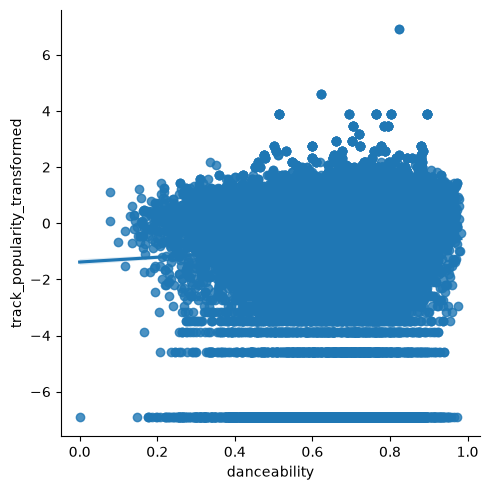

In [36]:
# 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'

sns.lmplot(data = df, x = 'danceability', y = 'track_popularity_transformed')
plt.show()

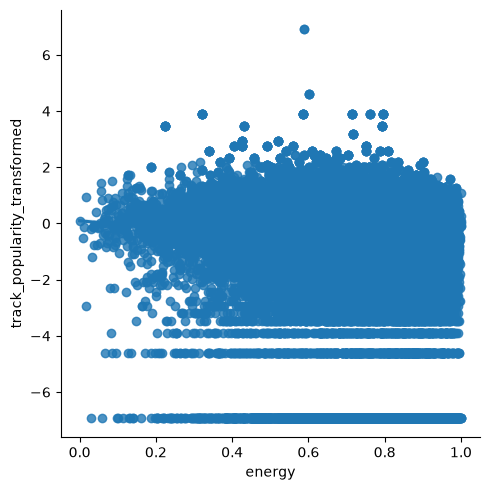

In [37]:
# 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'

sns.lmplot(data = df, x = 'energy', y = 'track_popularity_transformed')
plt.show()

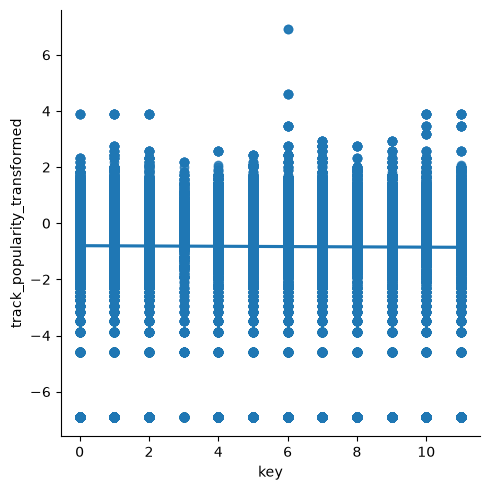

In [29]:
# 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'

sns.lmplot(data = df, x = 'key', y = 'track_popularity_transformed')
plt.show()

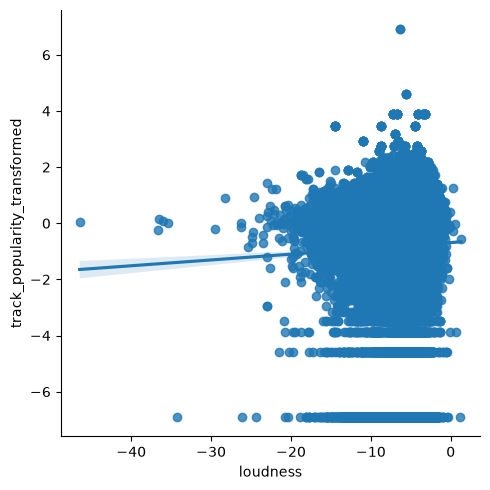

In [30]:
# 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'

sns.lmplot(data = df, x = 'loudness', y = 'track_popularity_transformed')
plt.show()

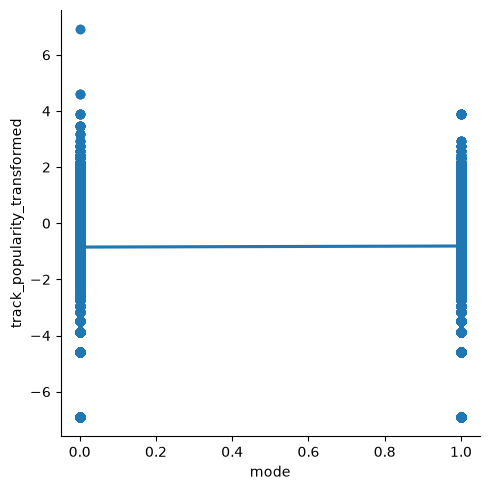

In [31]:
# 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'

sns.lmplot(data = df, x = 'mode', y = 'track_popularity_transformed')
plt.show()

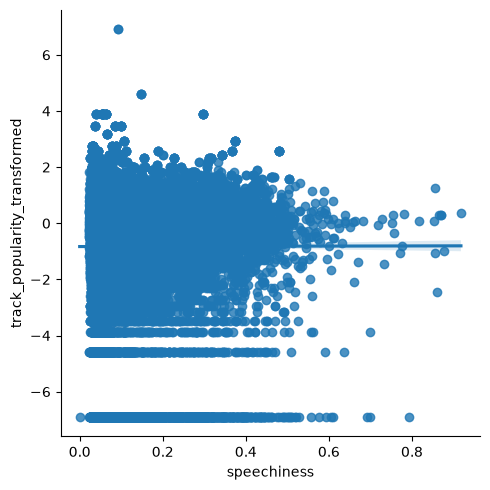

In [38]:
# 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'

sns.lmplot(data = df, x = 'speechiness', y = 'track_popularity_transformed')
plt.show()

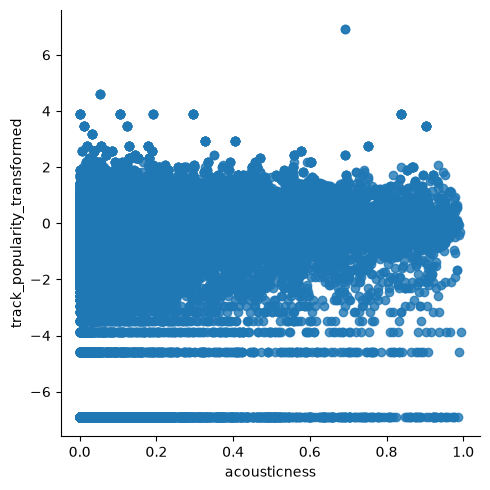

In [32]:
# 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'

sns.lmplot(data = df, x = 'acousticness', y = 'track_popularity_transformed')
plt.show()

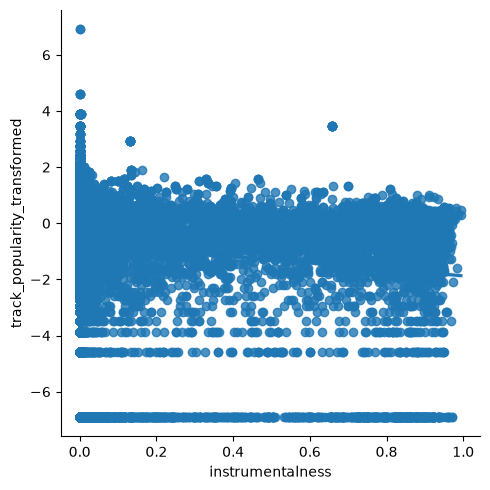

In [33]:
# 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'

sns.lmplot(data = df, x = 'instrumentalness', y = 'track_popularity_transformed')
plt.show()

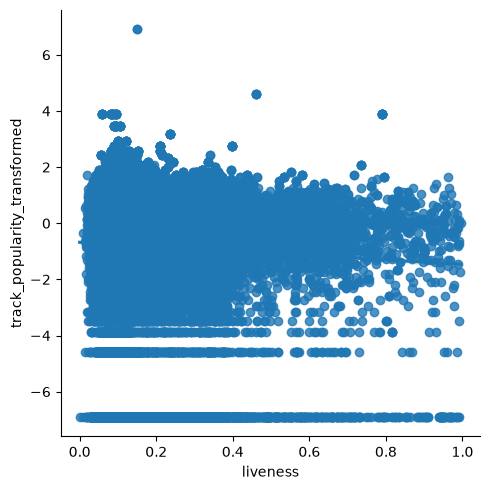

In [34]:
# 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'

sns.lmplot(data = df, x = 'liveness', y = 'track_popularity_transformed')
plt.show()

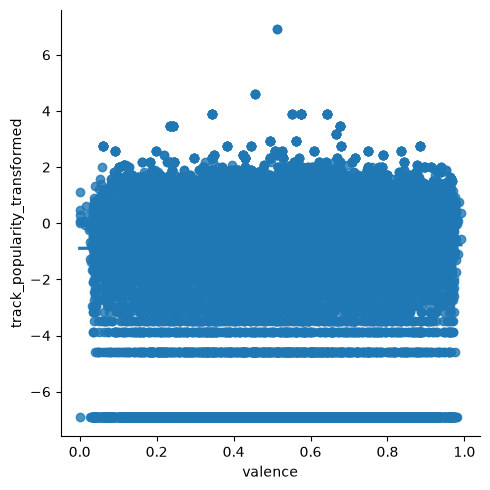

In [39]:
# 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'

sns.lmplot(data = df, x = 'valence', y = 'track_popularity_transformed')
plt.show()

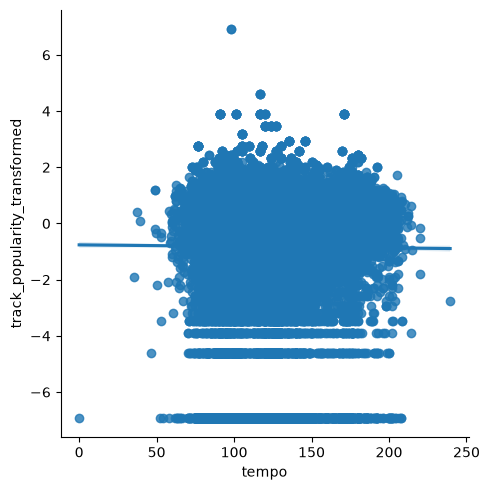

In [40]:
# 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'

sns.lmplot(data = df, x = 'tempo', y = 'track_popularity_transformed')
plt.show()

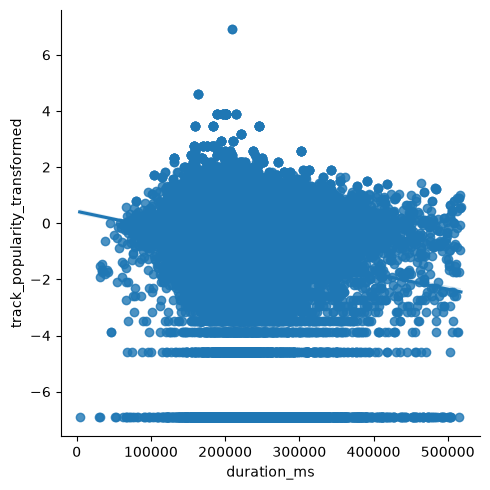

In [35]:
# 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'

sns.lmplot(data = df, x = 'duration_ms', y = 'track_popularity_transformed')
plt.show()

***

<span style="color:#17A697">

# Part 3: Model Predictions

In this section, you will consider multiple formulations (sets of features) for linear regression models and study the coefficients and their confidence intervals to interpret feature importance and quantify relationships to the transformed outcome variable. Before fitting models, if your EDA revealed that continuous variables have vastly different scales, standardize the variables before modeling. Feel free to make additional plots outside of what you completed for the EDA assignment if needed.

### Fit the following 6 models. You may fit additional models if you wish.

**Unlike the EDA assignment, please include all variables except ID variables and categorical variables with too many unique values,** unless the instructions note that you can use variables of your choice.

1. No INPUTS! Fit an INTERCEPT-ONLY or CONSTANT AVERAGE model.

2. Categorical inputs with additive features.

3. Continuous inputs with additive features.

4. All inputs (continuous and categorical) with additive features.

5. Inputs of your choice with linear main effects and pair-wise interactions. Select input variables that you think may be informative for prediction.

6. A nonlinear feature transformation on continuous variables of your choice. You can include any other non-transformed input variables you like if you wish. You can include polynomial transformations and/or sine or log-transformed variables. It's best if these transformations are informed by patterns you see in visualizations, but it's not required. You may include interaction variables if you wish.

### For each model that you fit you must answer the following questions associated with the regression coefficients:

1. How many coefficients were estimated?

2. WHICH coefficients (and thus features) are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

3. Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?

4. Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

5. Plot a predicted vs observed figure.

### Best model interpretation
Answer the following questions to summarize your model fitting exploration:

1. Which model has the best performance on the training set? Describe which features the model used, don't just give a number to refer to the model.

2. Is the best model according to R-squared the SAME as the best model according to RMSE? 

3. Is the best model better than the INTERCEPT-ONLY model? How many coefficients are associated with the BEST model?

</span>

***

<span style="color:#17A697">

# Part 4: Model Generalization Performance with Cross-validation

You have assessed how well your models fit the data they used for training, but now it's time to estimate how well they perform on unseen data. You will use cross-validation to calculate a more reliable estimate of the model performance.

### Choose 3 models to compare: 

1. The model that performed best on the training set

2. A simple model (few features) of your choice

3. A model of medium to high complexity of your choice

Use cross-validation to evaluate the performance of each of the 3 models. You can choose the number of folds and performance metric to focus on.

If you are standardizing variables, make sure to estimate the standardization parameters only for the training folds and not on the test fold as well during cross-validation. Scikit-learn's Pipeline module may be helpful to handle this case.

Visualize the CROSS-VALIDATION results by showing the AVERAGE CROSS-VALIDATION performance metric with the 68% confidence interval for each model.

### Answer the following questions:

1. Which model is the BEST according to CROSS-VALIDATION?

2. How many regression coefficients are associated with the best model?

3. Is this model DIFFERENT from the model identified as the BEST according to the training set? Discuss.

</span>

***

## Formatting Styles


<span style="color:#17A697">

### Section

Lorem ipsum dolor sit amet, consectetur adipiscing.

</span>



<span style="color:#E2725B">

#### Subsection

Lorem ipsum dolor sit amet, consectetur adipiscing.

</span>
